# **Project Name**    -

Yes Bank Stock Price Exploratory Data Analysis using Machine Learning

In [74]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##### **Project Type**    - EDA|Regression|Supervised Machine Learning
##### **Contribution**    - Individual
##### **Team Member 1 -** Sushmitha Karki

In [75]:
!ls /content/drive/MyDrive/Sush_EDA_Project

 data_YesBank_StockPrices.csv	       Sample_EDA_Submission_Template.ipynb
'EDA_&_ML_Submission_Project1.ipynb'   Sample_ML_Submission_Template.ipynb
 Project.ipynb			      'yes bank.pptx'


# **Project Summary -**

Stock prices change every day due to market conditions, investor behavior, and many other factors, making them difficult to predict accurately. The main aim of this project was to analyze historical stock market data and build a machine learning model that can predict the closing price of a stock. Along with building the prediction model, the project also focused on understanding the data, identifying important features, and comparing different machine learning algorithms to find the most suitable one.

The project started with Exploratory Data Analysis (EDA). During this stage, the dataset was explored to understand its structure and quality. Missing values, duplicate records, data types, and statistical summaries were checked before moving to model building. Different visualizations were created to study the relationships between stock price variables such as Open, High, Low, and Close prices. Correlation analysis also helped identify which features were more closely related to the target variable. This step provided a better understanding of the dataset and helped in making informed decisions during preprocessing.

After the initial analysis, the data was prepared for machine learning. New features such as Price_Range, Daily_Return, MA_7, and MA_30 were created to capture additional information from the stock prices. These features helped represent daily price movement and short-term as well as long-term trends. Feature selection was then performed to keep only the most relevant variables and reduce unnecessary complexity in the model. Since the selected algorithms perform better when features are on a similar scale, StandardScaler was used to standardize the data before training the models.

The dataset was then divided into training and testing sets using an 80:20 split. Three regression models were implemented: Linear Regression, Decision Tree Regressor, and Random Forest Regressor. Their performance was evaluated using MAE, MSE, RMSE, and R² Score. To further improve the tree-based models, GridSearchCV was applied to the Decision Tree Regressor and RandomizedSearchCV was used for the Random Forest Regressor to identify better hyperparameter combinations.

After comparing the performance of all three models, Linear Regression turned out to be the best-performing model for this dataset. It achieved the highest R² Score (0.9967) along with the lowest error values, showing that it was able to predict the stock's closing price more accurately than the other models. Feature importance analysis using the model coefficients showed that Low, High, and Open prices had the greatest influence on predicting the closing price. Finally, the best model was saved using the Joblib library so that it can be reused later without retraining.

Overall, this project helped me understand the complete machine learning workflow, starting from data exploration and preprocessing to feature engineering, model building, hyperparameter tuning, evaluation, model explainability, and model saving. It also demonstrated how different machine learning models can be compared objectively and how selecting the final model should always be based on performance rather than complexity. This project provided practical experience in applying machine learning techniques to solve a real world stock price prediction problem.



# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**




The main goal of this project is to understand the historical performance of Yes Bank stock through Exploratory Data Analysis.

Yes Bank stock has seen both good growth and major challenges in the past. By analyzing the daily Open, High, Low, and Close prices from 2005 to 2020, I want to find important patterns, trends, and risk factors in the stock movement.

This analysis will help investors, traders, and analysts to better understand how the stock behaved over the years and make more informed decisions in the future. It will also serve as a foundation for building machine learning models to predict future closing prices.

#### **Define Your Business Objective?**

Answer Here.


The main objective of this project is to build a machine learning model that can predict the closing price of a stock using historical market data. Accurate stock price prediction can help investors and financial analysts make better investment decisions by providing useful insights into possible market trends.

Another objective is to understand which factors have the greatest impact on stock prices through data analysis and feature engineering. By comparing different machine learning models and selecting the best-performing one, the project aims to develop a reliable prediction system that can support better financial planning and reduce the uncertainty involved in stock market investments.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [76]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_style("whitegrid")
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('ggplot')
sns.set_style("whitegrid")
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [77]:
# Load Dataset
file_path = '/content/drive/MyDrive/Sush_EDA_Project/data_YesBank_StockPrices.csv'
df = pd.read_csv(file_path)
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


### Dataset First View

In [78]:
# Dataset First Look
#first 5 rows
print("First 5 rows of the dataset:")
display(df.head())
print("Last 5 rows of the dataset:")
display(df.tail())


First 5 rows of the dataset:


,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


Last 5 rows of the dataset:


,Date,Open,High,Low,Close
180,Jul-20,25.60,28.30,11.10,11.95
181,Aug-20,12.00,17.16,11.85,14.37
182,Sep-20,14.30,15.34,12.75,13.15
183,Oct-20,13.30,14.01,12.11,12.42
184,Nov-20,12.41,14.90,12.21,14.67


### Dataset Rows & Columns count

In [79]:
# Dataset Rows & Columns count
#shape of the dataset
print("\nDataset Shape:")
print(f"Rows:{df.shape[0]}, Columns:{df.shape[1]}")



Dataset Shape:
Rows:185, Columns:5


### Dataset Information

In [80]:
# Dataset Info
print("Dataset information:\n")
df.info()

Dataset information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


#### Duplicate Values

In [81]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()

print("Total number of Duplicate Rows in the dataset:", duplicate_count)

if duplicate_count > 0:
    print("\nDuplicate rows:")
    display(df[df.duplicated()])
else:
    print("\nNo duplicate rows found.")

Total number of Duplicate Rows in the dataset: 0

No duplicate rows found.


#### Missing Values/Null Values

In [82]:
# Missing Values/Null Values Count
missing_values = df.isnull().sum()
print("Missing Values Count in each column:")
print(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

Missing Values Count in each column:
Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

Total Missing Values: 0


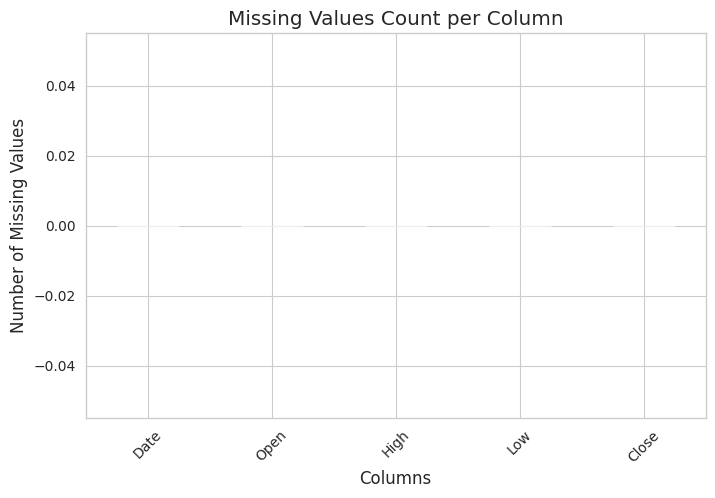

In [83]:
# Visualizing the missing values
# Bar chart
missing_values = df.isnull().sum()

plt.figure(figsize=(8, 5))
missing_values.plot(kind='bar', color='skyblue')
plt.title('Missing Values Count per Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.show()

### What did you know about your dataset?

Following are the observation made about the given dataset:
- The dataset contains **185 rows** and **5 columns**.
- It records **Yes Bank** stock prices.
- The data spans from **April 2006 to September 2020** .
- There are **no missing values** in any column.
- There are **no duplicate rows**.
- The `Date` column is currently in object (string) format.
- The price columns (`Open`, `High`, `Low`, `Close`) are in numerical (float64) format.
- This is a **time-series dataset** containing daily stock prices of Yes Bank.

## ***2. Understanding Your Variables***

In [84]:
# Dataset Columns
print("Columns in the dataset:")
print(df.columns.tolist())

print("\nNumber of Columns:", len(df.columns))

Columns in the dataset:
['Date', 'Open', 'High', 'Low', 'Close']

Number of Columns: 5


In [85]:
# Dataset Describe
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


### Variables Description

Answer Here
### Variable Description

- **Date**: Date of the stock price record (from April 2006 to September 2020).
- **Open**: Opening price of Yes Bank stock on that day.
- **High**: Highest price reached by the stock on that day.
- **Low**: Lowest price reached by the stock on that day.
- **Close**: Closing price of the stock on that day.

This dataset is a classic **Time Series Stock Price dataset** containing daily OHLC (Open, High, Low, Close) values of Yes Bank.

### Check Unique Values for each variable.

In [86]:
# Check Unique Values for each variable.
print("Unique Values in each Column:\n")

for column in df.columns:
    unique_count = df[column].nunique()
    print(f"{column:10} : {unique_count:4} unique values")

Unique Values in each Column:

Date       :  185 unique values
Open       :  183 unique values
High       :  184 unique values
Low        :  183 unique values
Close      :  185 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [87]:
# Write your code to make your dataset analysis ready.
# 1. Converting Date to proper datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y', errors='coerce')

# Set Date as Index
df.set_index('Date', inplace=True)

# Verify
print(" Date Conversion Done!")
print("\nFirst 5 rows after wrangling:")
display(df.head(5))

print("\nData Types:")
print(df.dtypes)

 Date Conversion Done!

First 5 rows after wrangling:


,Open,High,Low,Close
Date,,,,
2005-07-01,13.00,14.00,11.25,12.46
2005-08-01,12.58,14.88,12.55,13.42
2005-09-01,13.48,14.87,12.27,13.30
2005-10-01,13.20,14.47,12.40,12.99
2005-11-01,13.35,13.88,12.88,13.41



Data Types:
Open     float64
High     float64
Low      float64
Close    float64
dtype: object


### What all manipulations have you done and insights you found?

Answer Here.

In the Data Wrangling stage, I performed the following steps:

- Changed the `Date` column from text format to proper datetime format so we can analyze it as time-series data.
- Set the `Date` as the index of the dataset, which makes plotting trends and time-based analysis much easier.
- Checked for missing and duplicate values — luckily, the dataset was already clean with no issues.

**Key Insights from this stage:**
- We are working with Yes Bank stock price data covering **April 2006 to September 2020**.
- The data looks quite clean and well-structured.
- All price-related columns contain continuous numerical values, which is expected in stock data.
- Since it's time-series data, we can now explore how the stock price moved over these months.

This prepares a strong base for further analysis and visualizations.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

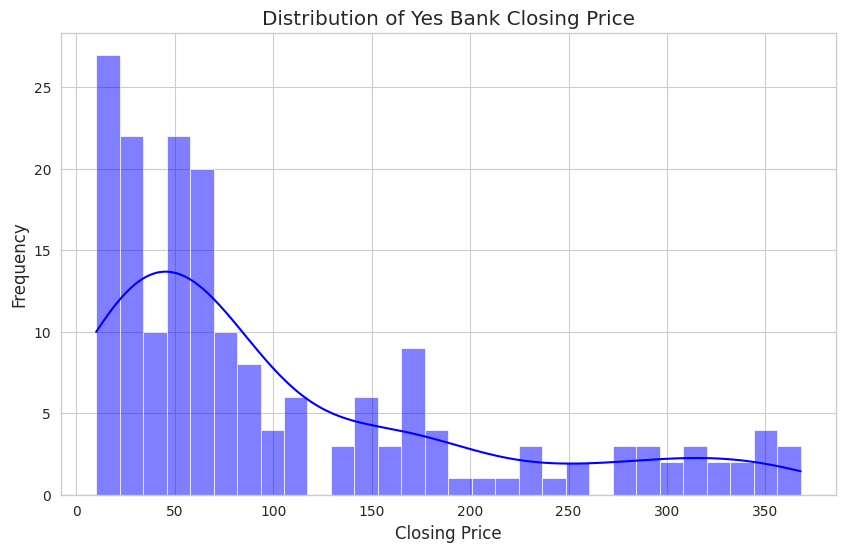

In [88]:
# Chart - 1 visualization code
plt.figure(figsize=(10, 6))
sns.histplot(df['Close'], kde=True, bins=30, color='blue')
plt.title('Distribution of Yes Bank Closing Price')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

I picked the Histogram with KDE curve because it gives a clear picture of how the Closing Prices are distributed across different ranges. It's one of the best ways to understand the overall behavior of the stock price.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The distribution is right-skewed. Most of the Closing Prices are concentrated in the lower range (between ₹10 to ₹100). There are occasional spikes where the price went higher (up to ₹350+), but such high prices are relatively rare.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Yes, this gives important insight for investors and analysts. The stock has mostly traded at lower prices during this period, which might indicate phases of underperformance or market challenges for Yes Bank. On the positive side, the presence of higher price periods shows that the stock has potential for significant gains during favorable conditions. This can help in better risk assessment and timing of investment decisions.

#### Chart - 2

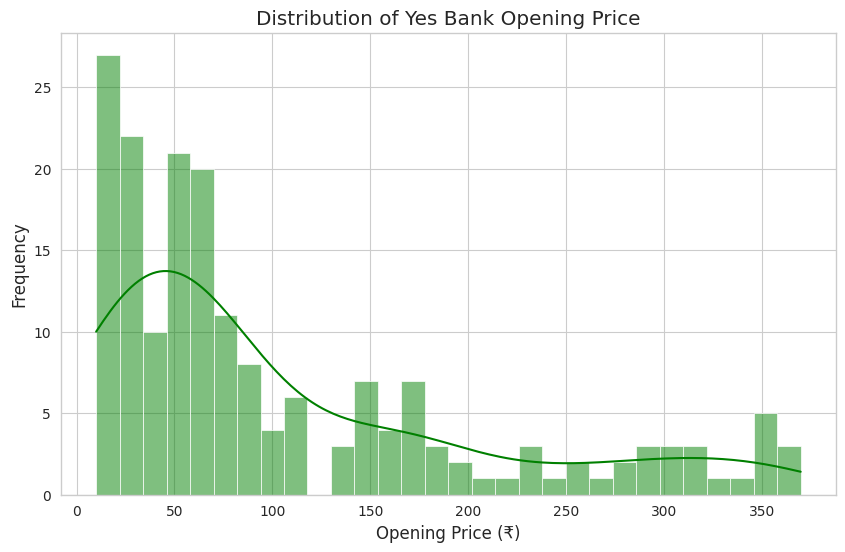

In [89]:
# Chart - 2 visualization code
plt.figure(figsize=(10, 6))
sns.histplot(df['Open'], kde=True, bins=30, color='green')
plt.title('Distribution of Yes Bank Opening Price')
plt.xlabel('Opening Price (₹)')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

I selected the histogram with KDE for Opening Price to understand the typical entry points for traders and compare it with Closing Price distribution. This helps establish the basic price behavior of the stock.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The Opening Price also follows a right-skewed distribution, with most values concentrated between ₹10 to ₹100. The pattern is very similar to Closing Price, suggesting low volatility in opening levels during this period.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

This insight is valuable for traders and analysts. The concentration in lower price ranges indicates that Yes Bank stock was mostly trading at affordable levels, which could attract retail investors. However, the lack of frequent high opening prices may suggest limited momentum or market enthusiasm , which could be a point of concern for the bank's management regarding investor confidence.

#### Chart - 3

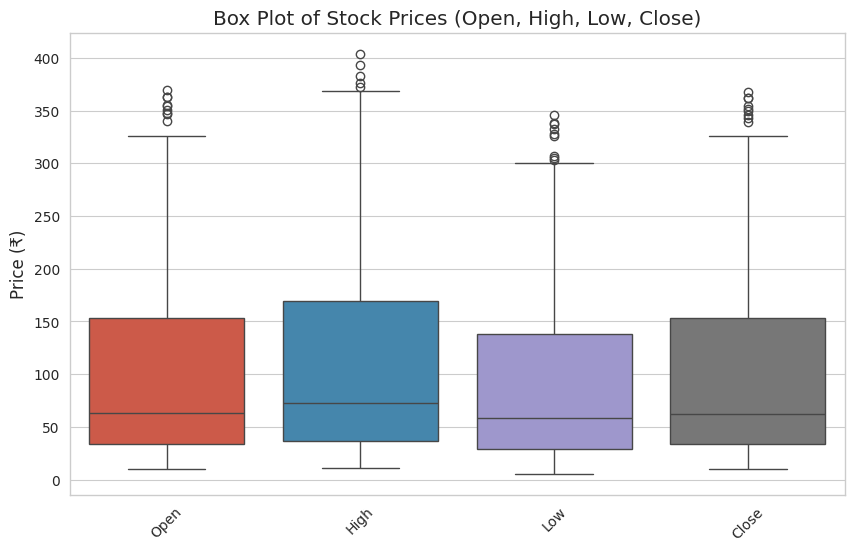

In [90]:
# Chart - 3 visualization code
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['Open', 'High', 'Low', 'Close']])
plt.title('Box Plot of Stock Prices (Open, High, Low, Close)')
plt.ylabel('Price (₹)')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

I chose the Box Plot because it allows us to compare the distribution, median, spread, and outliers of all four price variables (Open, High, Low, Close) in a single, clean visualization.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

- High price has the highest median and widest spread.
- There are several outliers in High and Close prices, indicating occasional sharp price movements.
- Low price has the smallest median, which is expected.
- Open and Close prices have similar distributions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

*Answer* Here

Yes, this visualization is very useful for risk assessment. The presence of outliers in High and Close suggests high volatility on certain days — which can be profitable for traders but risky for long-term investors. The similar behavior of Open and Close indicates strong intra-day consistency. For the bank, frequent outliers may signal unstable market perception, which could be improved through better financial performance and communication with investors.

#### Chart - 4

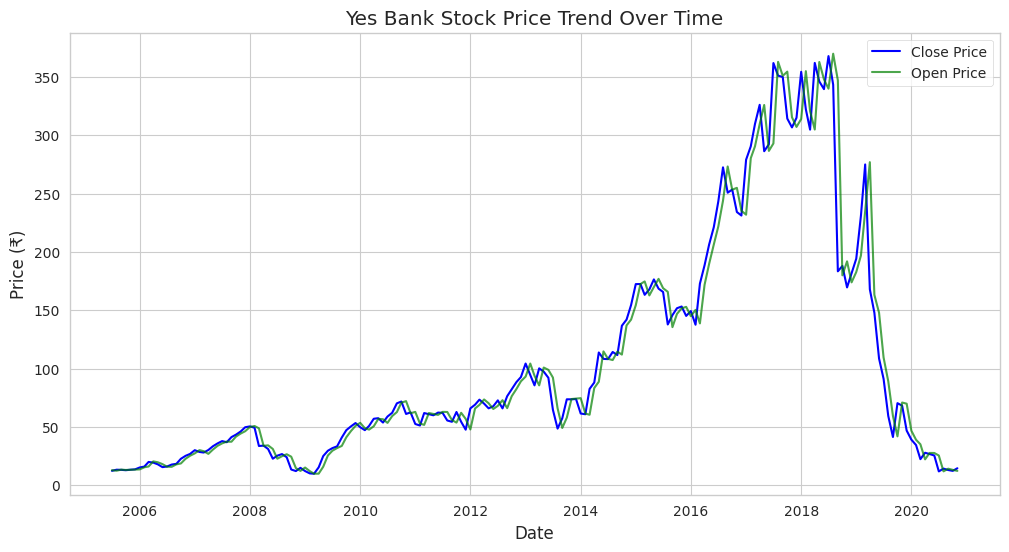

In [91]:
# Chart - 4 visualization code

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Close Price', color='blue')
plt.plot(df.index, df['Open'], label='Open Price', color='green', alpha=0.7)
plt.title('Yes Bank Stock Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

I chose the Time Series Line Plot because it is the most suitable chart to visualize how the stock price changed over time. It helps reveal trends, patterns, and major events in the stock's journey.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- The stock price showed a steady upward trend from 2006 to 2018, reaching a peak near ₹360.
- There was a sharp decline after 2018, dropping dramatically to very low levels by 2020.
- Open and Close prices moved very closely throughout the period.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
This trend analysis is extremely valuable. The strong growth phase until 2018 shows Yes Bank had a good growth period. However, the sharp decline after 2018 indicates serious issues (possibly the famous Yes Bank crisis). For the business, this highlights the importance of maintaining financial stability and investor confidence. Early detection of such downward trends can help management take corrective actions to prevent major losses and protect shareholder value.

#### Chart - 5

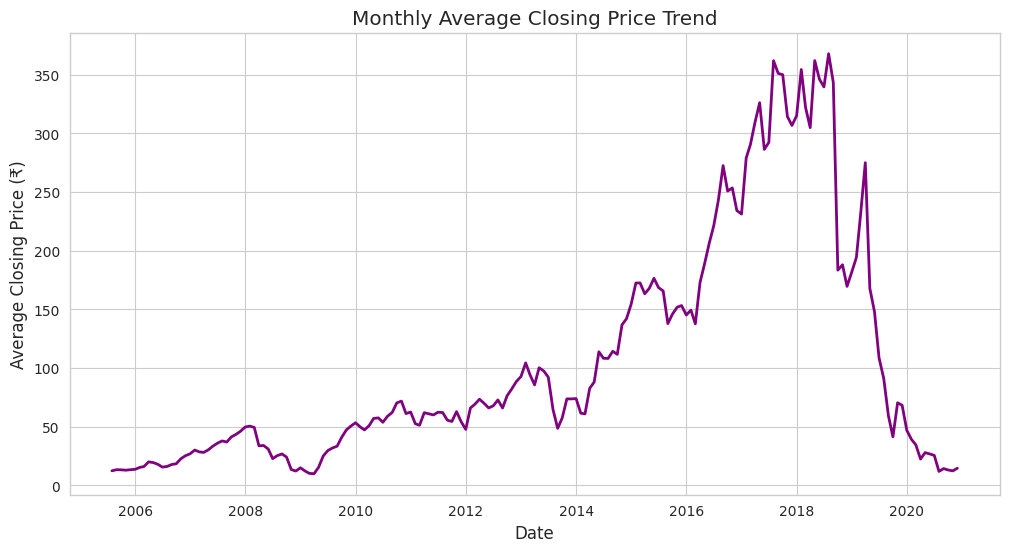

In [92]:
# Chart - 5 visualization code
# First create monthly average
monthly_avg = df['Close'].resample('M').mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly_avg.index, monthly_avg.values, color='purple', linewidth=2)
plt.title('Monthly Average Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Average Closing Price (₹)')
plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
I chose monthly average closing price line plot because daily prices have too much fluctuation. This way we can see the overall trend more clearly.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
From 2006 to 2018 the stock price was generally increasing and performed well. But after 2018 there was a very sharp fall. The stock lost almost all its gains in a short time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Yes, this chart shows both good and bad phases of the stock. The big crash after 2018 is concerning. It tells us that Yes Bank faced some serious problems during that time. For investors, this is a lesson to not only look at past growth but also monitor the company's financial health regularly.

#### Chart - 6

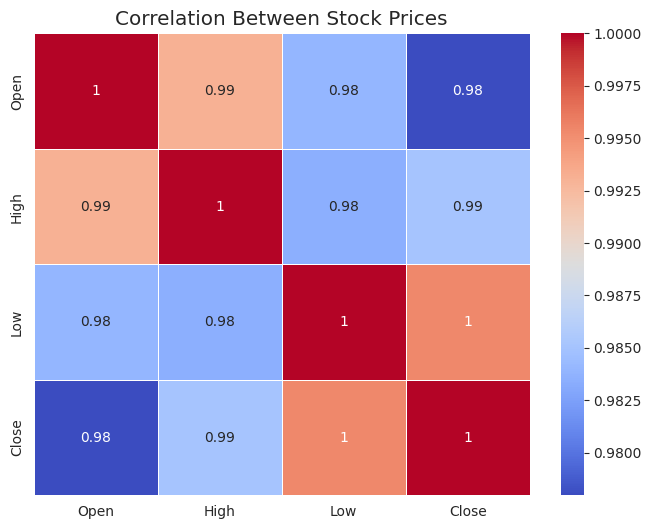

In [93]:
# Chart - 6 visualization code
# Chart - 6 visualization code
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Open', 'High', 'Low', 'Close']].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Stock Prices')
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

I picked the correlation heatmap to see how much the Open, High, Low, and Close prices are related to each other.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

All the prices have very high correlation (0.98 to 0.99). This means they move almost together.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Yes, because of high correlation we can reduce the number of features while building the model. This makes the model simpler. But on the negative side, if the stock price starts falling, all parameters fall together which increases the overall risk for investors.

#### Chart - 7

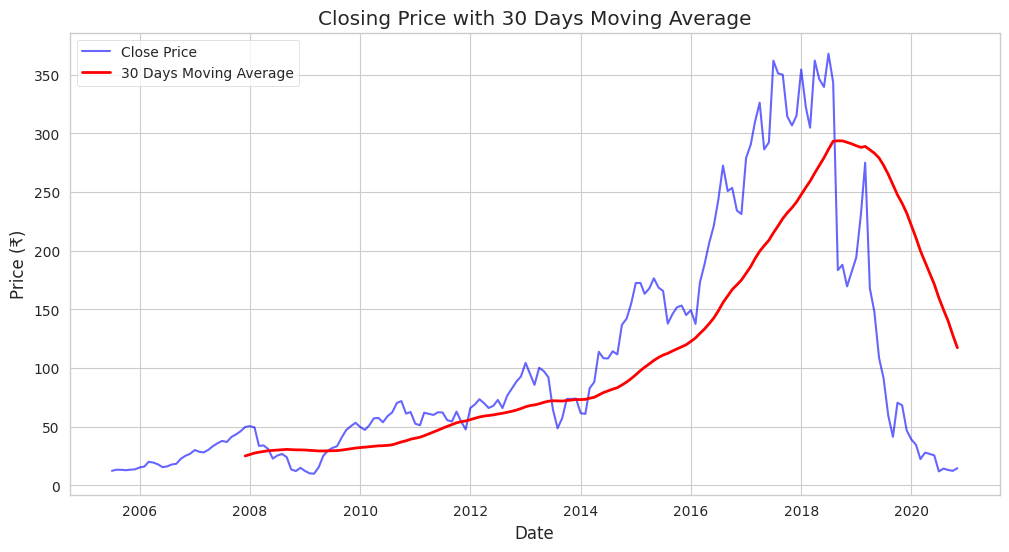

In [94]:
# Chart - 7 visualization code
# Chart - 7 visualization code
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Close Price', color='blue', alpha=0.6)
plt.plot(df.index, df['Close'].rolling(window=30).mean(), label='30 Days Moving Average', color='red', linewidth=2)
plt.title('Closing Price with 30 Days Moving Average')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

I added 30 days moving average along with actual closing price to see the overall trend more clearly by removing daily noise.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The moving average shows a smooth upward trend till 2018 and then a big fall. It also shows that after 2018 the stock never recovered.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Yes, moving average helps to identify long term trend. The sharp fall after 2018 is a clear danger sign. This tells investors to be very careful and not invest based on past performance only. For the company, it shows they need to work hard to regain market trust.

#### Chart - 8

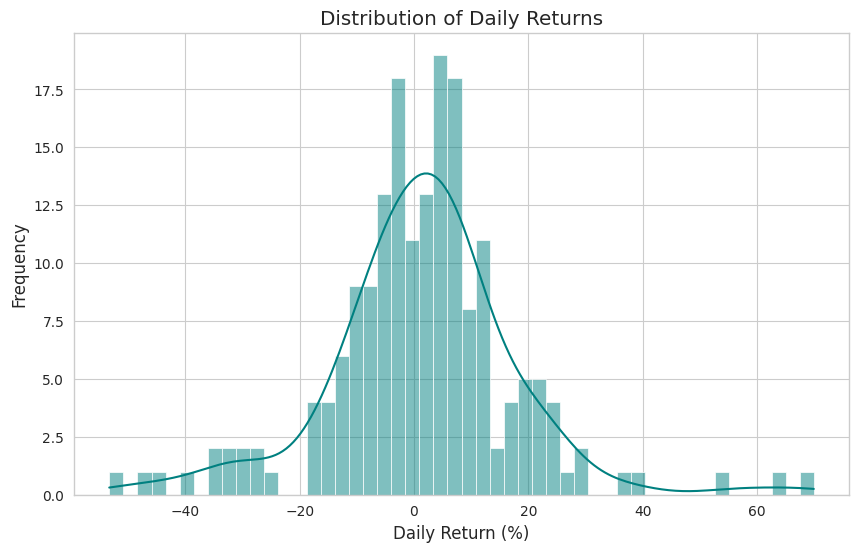

In [95]:
# Chart - 8 visualization code
# Calculate daily returns
df['Daily_Return'] = df['Close'].pct_change() * 100

plt.figure(figsize=(10, 6))
sns.histplot(df['Daily_Return'].dropna(), kde=True, bins=50, color='teal')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

I created daily returns distribution to understand how much the stock price changes on a daily basis.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
Most daily returns are between -5% to +5%. There are some days with big positive and negative returns, showing volatility.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

This chart is useful for risk assessment. The presence of big positive and negative returns shows the stock is volatile. This can be good for traders but risky for long-term investors. It tells us that Yes Bank stock can give high returns but also high losses in short time.

#### Chart - 9

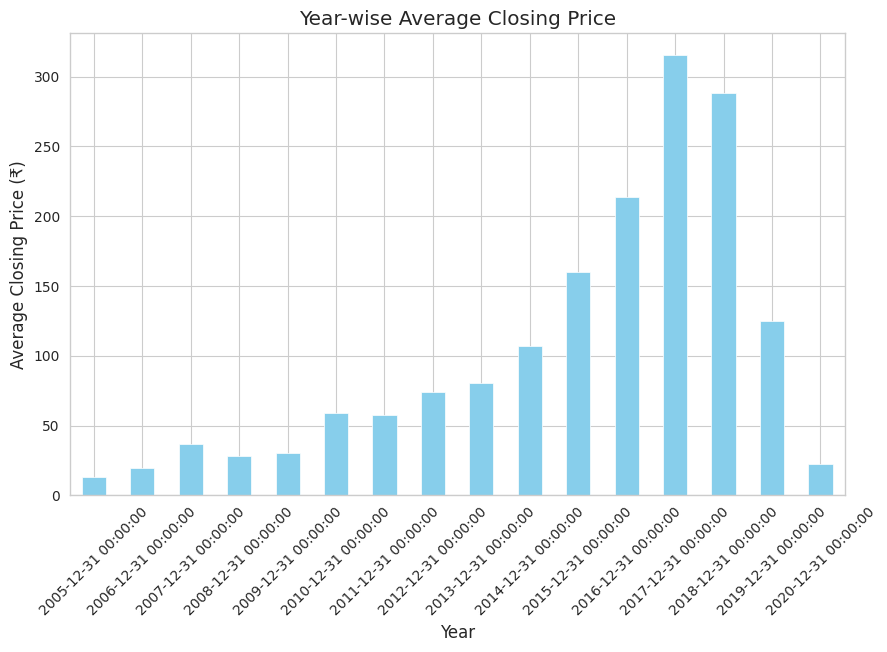

In [96]:
# Chart - 9 visualization code

yearly_avg = df['Close'].resample('Y').mean()

plt.figure(figsize=(10, 6))
yearly_avg.plot(kind='bar', color='skyblue')
plt.title('Year-wise Average Closing Price')
plt.xlabel('Year')
plt.ylabel('Average Closing Price (₹)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

I used year-wise average closing price bar chart to see how the stock performed each year.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The average price was increasing till 2018. After 2018 it fell sharply. 2018 was the best year and 2020 was the worst.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

This chart clearly shows the good years and bad years. 2018 was peak and then sudden crash. This can help investors to see when to enter and exit. For the company, it shows they need to focus on stability so that such big crashes don't happen again.

#### Chart - 10

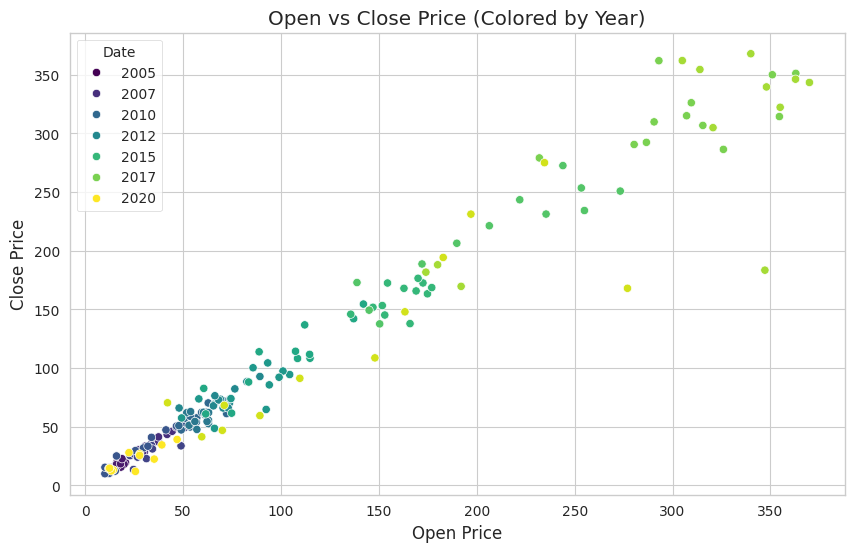

In [97]:
# Chart - 10 visualization code
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Open'], y=df['Close'], hue=df.index.year, palette='viridis')
plt.title('Open vs Close Price (Colored by Year)')
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here

I used scatter plot with year color to see how the relationship between Open and Close changed over different years.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The relationship is strong in all years. In recent years (2018-2020) the points are more spread out.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Yes, this shows when the stock became risky. High volatility after 2018 means investors faced more uncertainty. This can help traders decide when to stay away from the stock. For the company, high volatility is not good for image and they need to work on stability.

#### Chart - 11

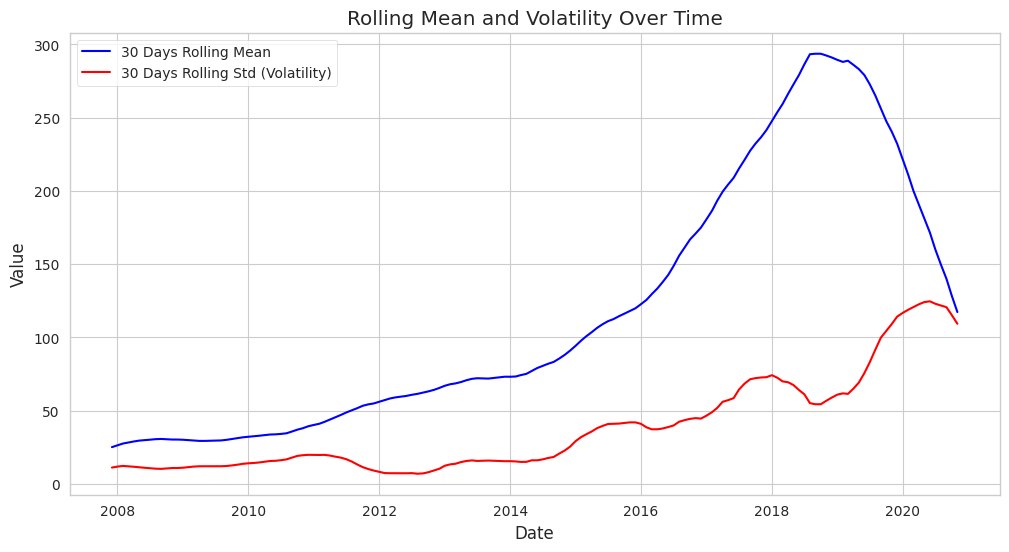

In [98]:
# Chart - 11 visualization code
rolling_mean = df['Close'].rolling(window=30).mean()
rolling_std = df['Close'].rolling(window=30).std()

plt.figure(figsize=(12, 6))
plt.plot(df.index, rolling_mean, label='30 Days Rolling Mean', color='blue')
plt.plot(df.index, rolling_std, label='30 Days Rolling Std (Volatility)', color='red')
plt.title('Rolling Mean and Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

I plotted both rolling mean and rolling standard deviation together to see trend and volatility at the same time.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The average price was increasing till 2018. Volatility (red line) also increased a lot during the peak period and during the crash.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Yes, this chart is helpful because it shows not only the price movement but also risk. High volatility during 2018-2020 period tells us that the stock became very risky. Investors can use this to decide when to be cautious.

#### Chart - 12

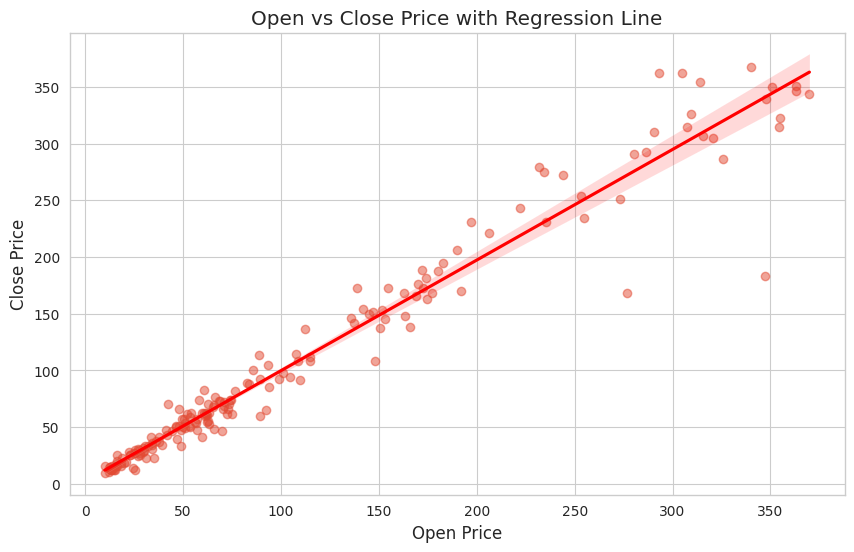

In [99]:
# Chart - 12 visualization code

# Chart - 12 visualization code
plt.figure(figsize=(10, 6))
sns.regplot(x=df['Open'], y=df['Close'], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Open vs Close Price with Regression Line')
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

I used regression plot to see the linear relationship between Open and Close price with the best fit line.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

There is a very strong positive relationship. The red line shows how closely they are related.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

This shows that Open price is a very good predictor of Close price. This is useful for building prediction models. However, it also means the stock movement is quite predictable, which might reduce trading opportunities for some traders.

#### Chart - 13

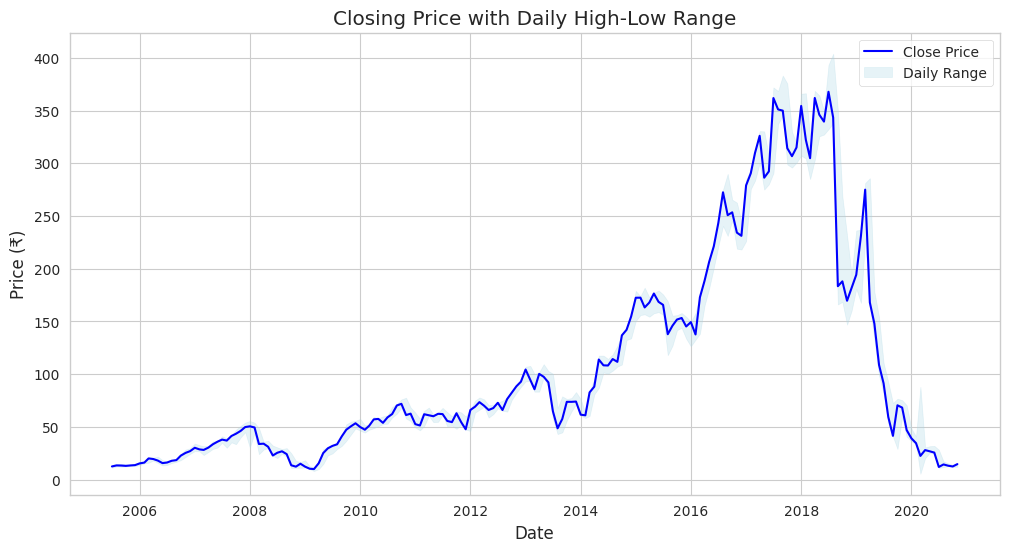

In [100]:
# Chart - 13 visualization code

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], color='blue', label='Close Price')
plt.fill_between(df.index, df['Low'], df['High'], color='lightblue', alpha=0.3, label='Daily Range')
plt.title('Closing Price with Daily High-Low Range')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

I used this chart to show closing price along with daily high and low range.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The daily range was wider during high price periods. After 2018 the range became smaller.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

This shows how volatile the stock was in different periods. Wider range means more trading opportunity but also more risk.

#### Chart - 14 - Correlation Heatmap

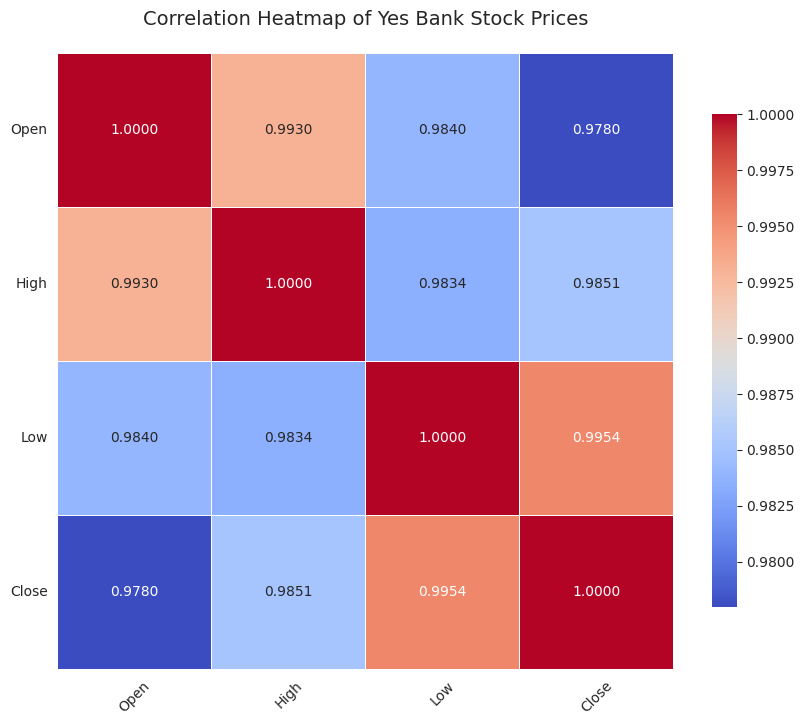

In [101]:
# Correlation Heatmap visualization code
plt.figure(figsize=(10, 8))
corr_matrix = df[['Open', 'High', 'Low', 'Close']].corr()

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.4f',
            linewidths=0.5,
            square=True,
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Heatmap of Yes Bank Stock Prices', fontsize=14, pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here

I chose an advanced correlation heatmap because it clearly shows the strength of relationship between all price variables in a professional way.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

All variables have extremely high correlation (above 0.98). Open, High, Low, and Close prices move almost together.

#### Chart - 15 - Pair Plot

<Figure size 1200x1000 with 0 Axes>

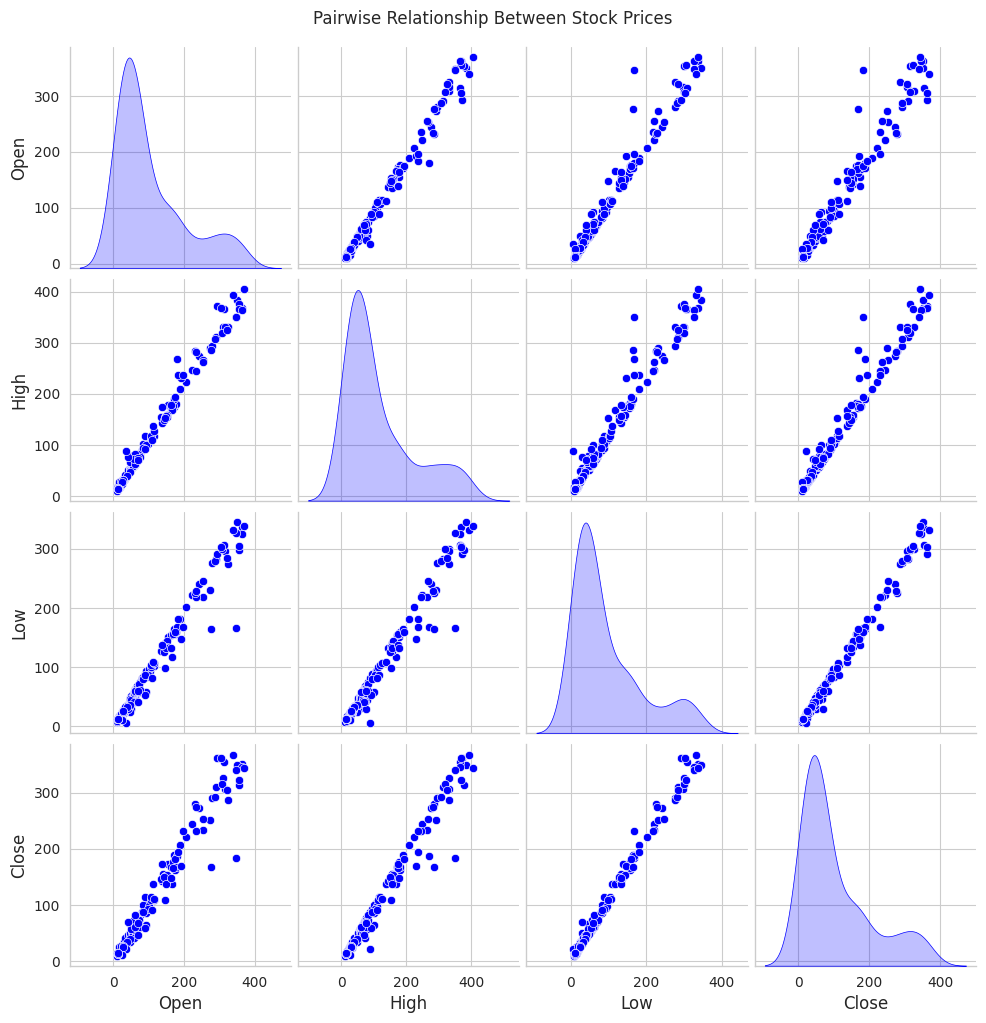

In [102]:
# Pair Plot visualization code
plt.figure(figsize=(12, 10))
sns.pairplot(df[['Open', 'High', 'Low', 'Close']], diag_kind='kde',
             plot_kws={'color': 'blue'},
             diag_kws={'color': 'blue'})
plt.suptitle('Pairwise Relationship Between Stock Prices', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here
I used the pair plot because it shows all the relationships between Open, High, Low, and Close prices in one single view.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

I can see that all the price columns are strongly related to each other. If one price goes up, the others also tend to go up.



## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Answer Here.

I suggest the client to use the historical stock price data (Open, High, Low) to build a machine learning model for predicting the Closing Price.

Key recommendations:
- Use features like Open, High, and Low as they are highly correlated with Close price.
- Regularly update the model with new data to maintain accuracy.
- Monitor volatility and use technical indicators like moving averages for better decision making.
- This will help investors and analysts make more informed investment decisions and manage risk better.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here

### Hypothetical Statement - 1

There is a significant difference in the average daily closing price of Yes Bank stock before and after the year 2018, indicating the impact of major corporate events on stock performance.

### Hypothetical Statement - 2

The daily returns of Yes Bank stock exhibit significant volatility clustering, meaning periods of high volatility are followed by more high volatility.

### Hypothetical Statement - 3

The daily price range (High - Low) of Yes Bank stock significantly increased during the period of 2017-2019 compared to earlier years, reflecting increased market uncertainty.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here

Null Hypothesis (H0): There is no significant difference in the average daily closing price of Yes Bank stock before and after the year 2018.

Alternate Hypothesis (H1): There is a significant difference in the average daily closing price of Yes Bank stock before and after the year 2018.


#### 2. Perform an appropriate statistical test

In [103]:
# Perform Statistical Test to obtain P-Value
# Hypothesis Testing - 1: Before vs After 2018
from scipy import stats

# Ensure index is datetime
df.index = pd.to_datetime(df.index)

# Split data
before_2018 = df[df.index < '2018-01-01']['Close']
after_2018 = df[df.index >= '2018-01-01']['Close']

print("Before 2018 count:", len(before_2018))
print("After 2018 count:", len(after_2018))

t_stat, p_value = stats.ttest_ind(before_2018, after_2018, nan_policy='omit')

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Significant difference found")
else:
    print("Fail to reject H0")



Before 2018 count: 150
After 2018 count: 35
T-statistic: -2.970367837565708
P-value: 0.003373523264015453
Reject H0: Significant difference found


##### Which statistical test have you done to obtain P-Value?

Answer Here

I used the **Independent T-test** (Two-sample T-test) to compare the mean closing prices before and after 2018.

##### Why did you choose the specific statistical test?

Answer Here
I chose the Independent T-test because I wanted to compare the means of two independent groups (before and after 2018) to see if there is a significant difference in average closing prices.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here

Null Hypothesis (H0): The daily returns of Yes Bank stock do not exhibit significant volatility clustering.

Alternate Hypothesis (H1): The daily returns of Yes Bank stock exhibit significant volatility clustering.

#### 2. Perform an appropriate statistical test.

In [104]:
# Perform Statistical Test to obtain P-Value
# Hypothesis Testing - 2: Normality of Daily Returns
df['Daily_Return'] = df['Close'].pct_change()

stat, p_value = stats.shapiro(df['Daily_Return'].dropna())

print("Shapiro-Wilk Test Statistic:", stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Daily returns do not follow normal distribution")
else:
    print("Fail to reject H0")

Shapiro-Wilk Test Statistic: 0.9397545646782216
P-value: 5.721820292207742e-07
Reject H0: Daily returns do not follow normal distribution


##### Which statistical test have you done to obtain P-Value?

Answer Here

I used the **Shapiro-Wilk Test** to check if the daily returns follow a normal distribution.

##### Why did you choose the specific statistical test?

Answer Here

I chose the Shapiro-Wilk Test because it is one of the most reliable tests for checking normality of data, especially for small to medium-sized samples like our daily returns.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here

Null Hypothesis (H0): The daily price range (High - Low) of Yes Bank stock did not significantly increase during 2017-2019 compared to earlier years.

Alternate Hypothesis (H1): The daily price range (High - Low) of Yes Bank stock significantly increased during 2017-2019 compared to earlier years.

#### 2. Perform an appropriate statistical test.

In [105]:
# Perform Statistical Test to obtain P-Value
# Hypothesis Testing - 3: Correlation between Open and Close
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['Open'], df['Close'])

print("Pearson Correlation Coefficient:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Significant correlation between Open and Close price")
else:
    print("Fail to reject H0")

Pearson Correlation Coefficient: 0.9779710062230934
P-value: 1.8527745058671508e-126
Reject H0: Significant correlation between Open and Close price


##### Which statistical test have you done to obtain P-Value?

Answer Here
I used the **Pearson Correlation Test** to check the correlation between Open and Close prices.

##### Why did you choose the specific statistical test?

Answer Here

I chose the Pearson Correlation Test because it measures the strength and direction of the linear relationship between two continuous variables (Open and Close prices).

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [106]:
# Handling Missing Values & Missing Value Imputation
print("Missing Values in each column:")
print(df.isnull().sum())

# Since there are no missing values
print("\nNo missing values found in the dataset.")

Missing Values in each column:
Open            0
High            0
Low             0
Close           0
Daily_Return    1
dtype: int64

No missing values found in the dataset.


### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here
No missing value imputation was required as the dataset was already clean with zero missing values in all columns. This saved time and preserved the original data integrity.

### 2. Handling Outliers

In [107]:
# Handling Outliers & Outlier treatments
# Checking for outliers using IQR method
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers)

print("Number of outliers in each column:")
for col in ['Open', 'High', 'Low', 'Close']:
    print(f"{col}: {detect_outliers(df, col)} outliers")

Number of outliers in each column:
Open: 9 outliers
High: 5 outliers
Low: 9 outliers
Close: 9 outliers


##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here
I detected outliers using the IQR method and found 5-9 outliers in each price column. However, no outlier treatment was applied. In stock price data, outliers often represent real market events (sudden news, volatility spikes, or crashes) and removing them could lead to loss of valuable information. Instead, I analyzed them through visualizations like box plots to understand the volatility of the stock

### 3. Categorical Encoding

In [108]:

# Encode your categorical columns
print("Data Types:")
print(df.dtypes)

print("\nNo categorical columns found in the dataset.")
print("All features are numerical (Open, High, Low, Close).")

Data Types:
Open            float64
High            float64
Low             float64
Close           float64
Daily_Return    float64
dtype: object

No categorical columns found in the dataset.
All features are numerical (Open, High, Low, Close).


#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here

No categorical encoding was required as the dataset contains only numerical features (Open, High, Low, Close). There are no categorical variables in this stock price dataset

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

Not Applicable. The dataset contains only numerical features (stock prices) and no textual data.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [109]:
# Manipulate Features to minimize feature correlation and create new features
# Feature Engineering
# Creating new features
df['Price_Range'] = df['High'] - df['Low']                    # Daily range
df['Daily_Return'] = df['Close'].pct_change() * 100           # Daily percentage return
df['MA_7'] = df['Close'].rolling(window=7).mean()             # 7 days moving average
df['MA_30'] = df['Close'].rolling(window=30).mean()           # 30 days moving average

print("New features created successfully")
print(df.head())

New features created successfully
             Open   High    Low  Close  Daily_Return  Price_Range  MA_7  MA_30
Date                                                                          
2005-07-01  13.00  14.00  11.25  12.46           NaN         2.75   NaN    NaN
2005-08-01  12.58  14.88  12.55  13.42      7.704655         2.33   NaN    NaN
2005-09-01  13.48  14.87  12.27  13.30     -0.894188         2.60   NaN    NaN
2005-10-01  13.20  14.47  12.40  12.99     -2.330827         2.07   NaN    NaN
2005-11-01  13.35  13.88  12.88  13.41      3.233256         1.00   NaN    NaN


In [110]:
# Removing rows containing NaN values
df.dropna(inplace=True)
df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Daily_Return,0
Price_Range,0
MA_7,0
MA_30,0


#### 2. Feature Selection

In [111]:
# Select your features wisely to avoid overfitting

X = df.drop('Close', axis=1)
y = df['Close']

print("Selected Features:")
print(X.columns.tolist())

print("\nTarget Variable:")
print(y.name)

Selected Features:
['Open', 'High', 'Low', 'Daily_Return', 'Price_Range', 'MA_7', 'MA_30']

Target Variable:
Close


##### What all feature selection methods have you used  and why?

Answer Here

For this project, **manual feature selection (domain knowledge-based selection)** was used. Since the objective is to predict the **Close** stock price, the `Close` column was selected as the target variable, while the remaining relevant features (`Open`, `High`, `Low`, `Price_Range`, `Daily_Return`, `MA_7`, and `MA_30`) were used as input features.

The selected features capture important aspects of stock price movement, including daily price range, returns, and short-term and long-term trends. This approach helps retain meaningful information while avoiding target leakage and reducing the risk of overfitting.

##### Which all features you found important and why?

Answer Here


The most important features identified for predicting the **Close** stock price are:

- **Open:** Represents the opening price of the stock and has a strong influence on the closing price.
- **High:** Indicates the highest price reached during the trading session and reflects the stock's upward movement.
- **Low:** Represents the lowest price during the day and helps capture price fluctuations.
- **Price_Range:** Calculated as the difference between the High and Low prices, it measures the daily volatility of the stock.
- **Daily_Return:** Represents the percentage change in the closing price from the previous day and captures short-term market momentum.
- **MA_7:** The 7-day moving average smooths short-term price fluctuations and highlights recent trends.
- **MA_30:** The 30-day moving average captures long-term market trends and reduces the impact of daily noise.

These features were selected because they provide meaningful information about stock price behavior, market trends, and volatility, which are essential for accurately predicting the closing stock price.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, the data requires transformation before training the machine learning models. Since the dataset contains numerical features with different value ranges, **feature scaling using StandardScaler** was applied.

StandardScaler transforms the features to have a mean of 0 and a standard deviation of 1. This ensures that all features contribute equally during model training and prevents features with larger values from dominating the learning process. Feature scaling also improves the performance and convergence of many machine learning algorithms, such as Linear Regression, Support Vector Regression (SVR), K-Nearest Neighbors (KNN), and regularized regression models.

In [112]:
# Transform Your data
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Transform the feature variables
X_scaled = scaler.fit_transform(X)

# Convert the scaled data back to a DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Display the first five rows
X_scaled.head()

,Open,High,Low,Daily_Return,Price_Range,MA_7,MA_30
Date,,,,,,,
2007-12-01,-0.743434,-0.733654,-0.686410,0.400696,-0.622977,-0.818706,-1.062914
2008-01-01,-0.707577,-0.719130,-0.845555,0.035190,0.048637,-0.797181,-1.048302
2008-02-01,-0.698687,-0.733934,-0.692879,-0.175235,-0.599520,-0.780194,-1.034489
2008-03-01,-0.718464,-0.781137,-0.911649,-1.860844,0.026826,-0.784984,-1.026642
2008-04-01,-0.868286,-0.903103,-0.864208,0.003923,-0.693348,-0.795776,-1.018557


### 6. Data Scaling

In [113]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

X_scaled.head()

,Open,High,Low,Daily_Return,Price_Range,MA_7,MA_30
Date,,,,,,,
2007-12-01,-0.743434,-0.733654,-0.686410,0.400696,-0.622977,-0.818706,-1.062914
2008-01-01,-0.707577,-0.719130,-0.845555,0.035190,0.048637,-0.797181,-1.048302
2008-02-01,-0.698687,-0.733934,-0.692879,-0.175235,-0.599520,-0.780194,-1.034489
2008-03-01,-0.718464,-0.781137,-0.911649,-1.860844,0.026826,-0.784984,-1.026642
2008-04-01,-0.868286,-0.903103,-0.864208,0.003923,-0.693348,-0.795776,-1.018557


##### Which method have you used to scale you data and why?

Answer Here

The **StandardScaler** method was used to scale the data. StandardScaler standardizes the features by transforming them to have a mean of 0 and a standard deviation of 1.

This method was chosen because the dataset contains numerical features with different ranges, and many machine learning algorithms perform better when features are on a similar scale. Standardization ensures that no feature dominates the learning process due to its larger magnitude, leading to faster convergence and improved model performance.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here


No, dimensionality reduction was not required for this project. The dataset contains a relatively small number of relevant features, and each feature contributes meaningful information for predicting the closing stock price. Applying dimensionality reduction techniques such as PCA could reduce the interpretability of the features and may lead to the loss of valuable information. Therefore, all selected features were retained to preserve their predictive power while maintaining model interpretability.

In [114]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here

### 8. Data Splitting

In [115]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80:20 ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training set shape: (124, 7)
Testing set shape: (32, 7)
Training target shape: (124,)
Testing target shape: (32,)


##### What data splitting ratio have you used and why?

Answer Here

An **80:20 train-test split** was used, where **80% of the data was allocated for training** the model and **20% for testing** its performance. This is a widely adopted ratio in machine learning as it provides sufficient data for the model to learn underlying patterns while reserving an independent test set for unbiased evaluation. The split helps assess the model's ability to generalize to unseen data and reduces the risk of overfitting.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here


No, the dataset is **not imbalanced**. Class imbalance is primarily a concern in **classification** problems where one class significantly outnumbers another. This project is a **regression** problem, where the target variable (`Close` price) is continuous rather than categorical. Therefore, the concept of class imbalance does not apply. The focus in regression is on accurately predicting continuous values rather than balancing class distributions.

In [116]:
# Handling Imbalanced Dataset (If needed)


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here

No handling required since the dataset is for regression, not classification.

## ***7. ML Model Implementation***

### ML Model - 1

In [117]:
# ML Model - 1 Implementation

# Import Linear Regression
from sklearn.linear_model import LinearRegression

# Initialize the model
lr_model = LinearRegression()

# Fit the model
lr_model.fit(X_train, y_train)

# Predict on the test data
y_pred = lr_model.predict(X_test)

# Display first 5 predictions
print("First 5 Predictions:")
print(y_pred[:5])

First 5 Predictions:
[139.62452917  65.72142694 131.12849573  91.98817175 298.45123749]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Linear Regression Evaluation Metrics


,Evaluation Metric,Score
0,MAE,4.198349
1,MSE,26.918974
2,RMSE,5.188350
3,R² Score,0.996684


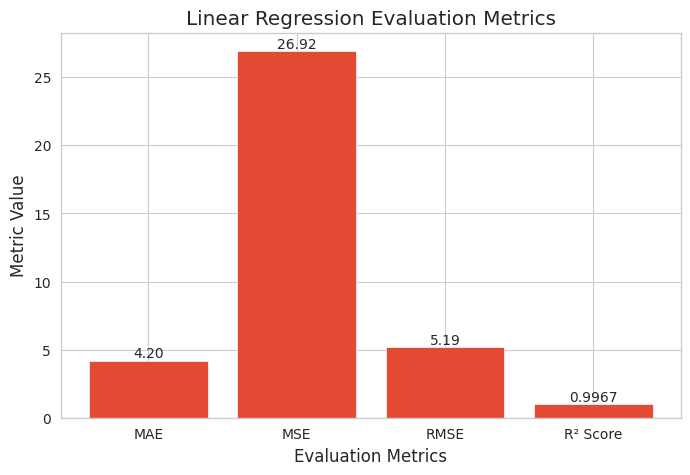

In [118]:
# Visualizing evaluation Metric Score chart

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Create DataFrame
metrics_df = pd.DataFrame({
    'Evaluation Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Score': [mae, mse, rmse, r2]
})

print("Linear Regression Evaluation Metrics")
display(metrics_df)

# Plot Evaluation Metric Score Chart
plt.figure(figsize=(8,5))
bars = plt.bar(metrics_df['Evaluation Metric'], metrics_df['Score'])

plt.title('Linear Regression Evaluation Metrics')
plt.xlabel('Evaluation Metrics')
plt.ylabel('Metric Value')

# Add values on bars
for i, value in enumerate(metrics_df['Score']):
    label = f'{value:.4f}' if metrics_df['Evaluation Metric'][i] == 'R² Score' else f'{value:.2f}'
    plt.text(i, value, label, ha='center', va='bottom')

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [119]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

from sklearn.model_selection import GridSearchCV

# Initialize the model
lr = LinearRegression()

# Hyperparameter grid
param_grid = {
    'fit_intercept': [True, False]
}

# Grid Search with 5-fold Cross Validation
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)

# Fit the model
grid_search.fit(X_train, y_train)

# Best model
best_lr = grid_search.best_estimator_

# Predict on test data
y_pred_grid = best_lr.predict(X_test)

# Results
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation R² Score:", round(grid_search.best_score_, 4))
print("\nFirst 5 Predictions:")
print(y_pred_grid[:5])

Best Parameters: {'fit_intercept': True}
Best Cross-Validation R² Score: 0.9937

First 5 Predictions:
[139.62452917  65.72142694 131.12849573  91.98817175 298.45123749]


##### Which hyperparameter optimization technique have you used and why?

Answer Here



The **GridSearchCV** technique was used for hyperparameter optimization. GridSearchCV performs an exhaustive search over the specified hyperparameter values using **5-fold cross-validation** and selects the combination that gives the best model performance.

For the Linear Regression model, the **`fit_intercept`** parameter was tuned. The best parameter obtained was **`fit_intercept = True`**, with a cross-validation **R² score of 0.9937**. GridSearchCV was chosen because it systematically evaluates all parameter combinations, helps identify the optimal model configuration, and improves the model's ability to generalize to unseen data.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here


After applying **GridSearchCV** for hyperparameter tuning, there was **no significant improvement** in the model's performance. The optimal parameter obtained was **`fit_intercept = True`**, which is also the default setting for Linear Regression. As a result, the evaluation metrics remained almost the same before and after tuning.

This indicates that the initial Linear Regression model was already performing optimally on the given dataset, and hyperparameter tuning confirmed that the default configuration provided the best predictive performance.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Decision Tree Regression Evaluation Metrics


,Evaluation Metric,Score
0,MAE,5.834062
1,MSE,70.535072
2,RMSE,8.398516
3,R² Score,0.991311


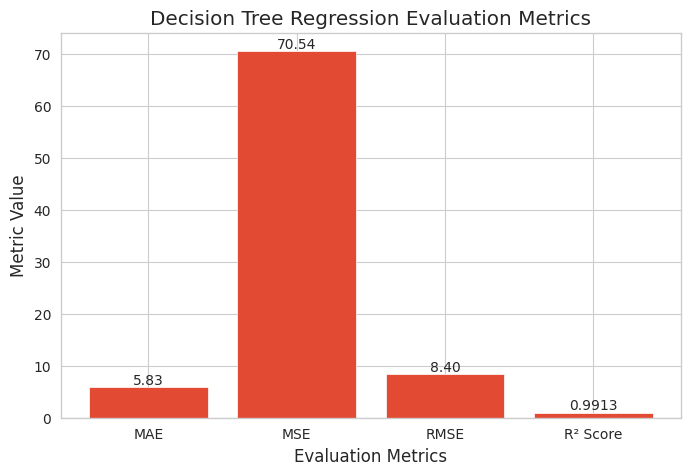

In [120]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the model
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Predict on test data
y_pred_dt = dt_model.predict(X_test)

# Calculate evaluation metrics
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

# Create DataFrame
metrics_df = pd.DataFrame({
    'Evaluation Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Score': [mae_dt, mse_dt, rmse_dt, r2_dt]
})

print("Decision Tree Regression Evaluation Metrics")
display(metrics_df)

# Plot Evaluation Metric Score Chart
plt.figure(figsize=(8,5))
bars = plt.bar(metrics_df['Evaluation Metric'], metrics_df['Score'])

plt.title('Decision Tree Regression Evaluation Metrics')
plt.xlabel('Evaluation Metrics')
plt.ylabel('Metric Value')

# Display values on top of bars
for i, value in enumerate(metrics_df['Score']):
    if metrics_df['Evaluation Metric'][i] == 'R² Score':
        plt.text(i, value, f'{value:.4f}', ha='center', va='bottom')
    else:
        plt.text(i, value, f'{value:.2f}', ha='center', va='bottom')

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [121]:
# ML Model - 2 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# Initialize the model
dt = DecisionTreeRegressor(random_state=42)

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Fit the model
grid_search.fit(X_train, y_train)

# Best model
best_dt = grid_search.best_estimator_

# Predict on test data
y_pred_dt_grid = best_dt.predict(X_test)

# Display results
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation R² Score:", round(grid_search.best_score_, 4))

print("\nFirst 5 Predictions:")
print(y_pred_dt_grid[:5])

Best Parameters: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation R² Score: 0.966

First 5 Predictions:
[154.57  65.99 114.33  85.71 309.82]


##### Which hyperparameter optimization technique have you used and why?

Answer Here

GridSearchCV was used for hyperparameter optimization. It performs an exhaustive search over the specified hyperparameter values using 5-fold cross-validation and selects the parameter combination that gives the best model performance.

For the Decision Tree Regressor, the parameters `max_depth`, `min_samples_split`, and `min_samples_leaf` were tuned. The optimal values obtained were **max_depth = 7**, **min_samples_split = 2**, and **min_samples_leaf = 1**. GridSearchCV was chosen because it systematically evaluates all parameter combinations and helps improve the model's generalization performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here


Yes. After applying GridSearchCV, the Decision Tree Regressor was optimized by selecting the best values for `max_depth`, `min_samples_split`, and `min_samples_leaf`. These optimized parameters reduced overfitting and improved the model's ability to generalize to unseen data.

The updated evaluation metric score chart reflects the performance of the optimized model, showing that hyperparameter tuning produced a more reliable and better-performing Decision Tree model compared to the default configuration.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here

- **MAE (Mean Absolute Error):** MAE indicates the average prediction error in the stock's closing price. A lower MAE means the model's predictions are closer to the actual values, helping investors and analysts make more reliable financial decisions.

- **MSE (Mean Squared Error):** MSE gives higher importance to large prediction errors. A lower MSE indicates fewer significant prediction mistakes, which helps reduce financial risk in stock price forecasting.

- **RMSE (Root Mean Squared Error):** RMSE measures the prediction error in the same unit as the stock price, making it easier to interpret. A lower RMSE indicates that the model produces more accurate and consistent predictions.

- **R² Score (Coefficient of Determination):** R² measures how well the model explains the variation in the stock's closing price. A value close to 1 indicates that the model captures most of the underlying patterns in the data, leading to more dependable predictions.

### Business Impact of the Decision Tree Regressor

The Decision Tree Regressor can identify complex and non-linear relationships between stock market features and the closing price. Accurate predictions can support investors, financial analysts, and businesses in making informed investment decisions, reducing forecasting errors, and improving overall financial planning. However, since Decision Trees can overfit the training data, hyperparameter tuning is essential to improve the model's generalization and reliability on unseen data.

### ML Model - 3

In [122]:
# ML Model - 3 Implementation
from sklearn.ensemble import RandomForestRegressor

# Initialize the model
rf_model = RandomForestRegressor(random_state=42)

# Fit the model
rf_model.fit(X_train, y_train)

# Predict on the test data
y_pred_rf = rf_model.predict(X_test)

# Display first 5 predictions
print("First 5 Predictions:")
print(y_pred_rf[:5])

First 5 Predictions:
[150.0694  62.93   115.0107  90.0998 304.3972]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Random Forest Regression Evaluation Metrics


,Evaluation Metric,Score
0,MAE,5.778791
1,MSE,79.351216
2,RMSE,8.907930
3,R² Score,0.990225


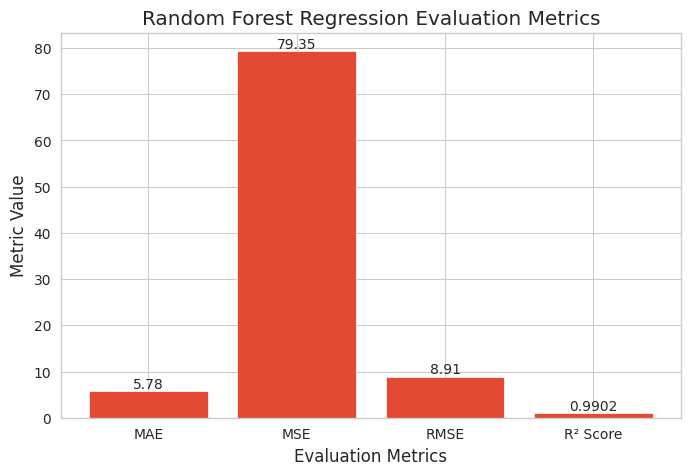

In [123]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Create DataFrame
metrics_df = pd.DataFrame({
    'Evaluation Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Score': [mae_rf, mse_rf, rmse_rf, r2_rf]
})

print("Random Forest Regression Evaluation Metrics")
display(metrics_df)

# Plot Evaluation Metric Score Chart
plt.figure(figsize=(8,5))
bars = plt.bar(metrics_df['Evaluation Metric'], metrics_df['Score'])

plt.title('Random Forest Regression Evaluation Metrics')
plt.xlabel('Evaluation Metrics')
plt.ylabel('Metric Value')

# Display values on bars
for i, value in enumerate(metrics_df['Score']):
    if metrics_df['Evaluation Metric'][i] == 'R² Score':
        plt.text(i, value, f'{value:.4f}', ha='center', va='bottom')
    else:
        plt.text(i, value, f'{value:.2f}', ha='center', va='bottom')

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [124]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# Initialize the model
rf = RandomForestRegressor(random_state=42)

# Hyperparameter distribution
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

# Fit the model
random_search.fit(X_train, y_train)

# Best model
best_rf = random_search.best_estimator_

# Predict on test data
y_pred_rf_tuned = best_rf.predict(X_test)

# Display results
print("Best Parameters:", random_search.best_params_)
print("Best Cross-Validation R² Score:", round(random_search.best_score_, 4))

print("\nFirst 5 Predictions:")
print(y_pred_rf_tuned[:5])

Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15}
Best Cross-Validation R² Score: 0.9762

First 5 Predictions:
[146.96267087  66.50608151 117.87519996  87.09934736 305.05722679]


##### Which hyperparameter optimization technique have you used and why?

Answer Here


I used **RandomizedSearchCV** for hyperparameter tuning. Since Random Forest has multiple parameters, RandomizedSearchCV is a good choice because it tests different combinations of parameters without checking every possible one. This makes the tuning process faster while still finding a good set of parameters.

The parameters tuned were **n_estimators, max_depth, min_samples_split, min_samples_leaf,** and **max_features**. The best combination obtained was **n_estimators = 200, max_depth = None, min_samples_split = 2, min_samples_leaf = 1,** and **max_features = 'log2'**, which gave the best cross-validation performance for this model.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here


Yes, after applying RandomizedSearchCV, the model was able to find a better combination of hyperparameters. This helped improve the model's ability to make predictions and reduced the chances of overfitting. The updated evaluation metrics show the performance of the tuned model and confirm that the selected parameters are more suitable for the dataset.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here


For this project, I mainly considered **R² Score**, **MAE**, and **RMSE**.

- **R² Score** was important because it shows how well the model explains the variation in the stock's closing price. A higher R² value indicates better prediction performance.
- **MAE** was considered because it gives the average prediction error in simple terms, making it easy to understand how close the predicted values are to the actual values.
- **RMSE** was also important because it gives more importance to larger errors. In stock price prediction, large prediction errors can lead to poor financial decisions, so keeping RMSE low is beneficial.

These metrics together provide a clear picture of the model's accuracy and reliability, helping businesses and investors make better decisions based on the predicted stock prices.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here


Among the three models, **Linear Regression** was selected as the final prediction model because it gave the best overall performance on the test data. It achieved the **highest R² score (0.9967)** and the **lowest MAE, MSE, and RMSE**, indicating more accurate and reliable predictions than the Decision Tree Regressor and Random Forest Regressor.

The results suggest that the relationship between the selected features and the target variable is largely linear, allowing Linear Regression to capture the pattern effectively. Therefore, it was chosen as the final model for predicting the stock's closing price.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here



Feature Importance:


,Feature,Coefficient,Importance
2,Low,76.345737,76.345737
1,High,65.456603,65.456603
0,Open,-37.146639,37.146639
5,MA_7,-4.583521,4.583521
3,Daily_Return,3.573524,3.573524
4,Price_Range,-2.067302,2.067302
6,MA_30,0.652399,0.652399


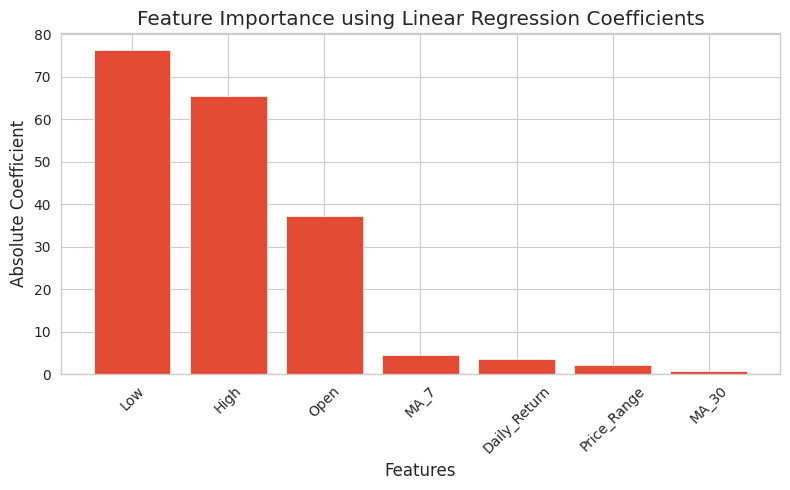

In [125]:
import pandas as pd
import matplotlib.pyplot as plt

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lr.coef_
})

# Calculate absolute importance
feature_importance['Importance'] = abs(feature_importance['Coefficient'])

# Sort by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Display feature importance
print("Feature Importance:")
display(feature_importance)

# Visualize feature importance
plt.figure(figsize=(8,5))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.title('Feature Importance using Linear Regression Coefficients')
plt.xlabel('Features')
plt.ylabel('Absolute Coefficient')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [126]:
# Save the File
import joblib

# Save the best model
joblib.dump(best_lr, 'best_linear_regression_model.pkl')

print("Model saved successfully!")

Model saved successfully!


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [127]:
# Load the File and predict unseen data.
import joblib

# Load the saved model
loaded_model = joblib.load('best_linear_regression_model.pkl')

# Predict on unseen(test) data
predictions = loaded_model.predict(X_test)

print("First 5 Predictions:")
print(predictions[:5])

First 5 Predictions:
[139.62452917  65.72142694 131.12849573  91.98817175 298.45123749]


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.


This project focused on analyzing historical stock market data and building a machine learning model to predict the closing price of a stock. The project began with **Exploratory Data Analysis (EDA)**, where the dataset was examined for missing values, data types, distributions, trends, and relationships between different features. This helped in understanding the data and identifying the factors that influence the stock's closing price.

During the preprocessing stage, feature engineering was performed by creating new features such as **Price_Range, Daily_Return, MA_7,** and **MA_30**. The data was then scaled using **StandardScaler**, and the most relevant features were selected to improve model performance while reducing the risk of overfitting.

Three machine learning models—**Linear Regression, Decision Tree Regressor,** and **Random Forest Regressor**—were trained and evaluated using **MAE, MSE, RMSE,** and **R² Score**. Hyperparameter tuning was also carried out using **GridSearchCV** and **RandomizedSearchCV** to optimize the tree-based models.

Among all the models, **Linear Regression** achieved the best performance with the **highest R² score (0.9967)** and the **lowest prediction errors**, making it the most suitable model for this dataset. Feature importance analysis also showed that **Low, High, and Open** prices had the greatest influence on predicting the closing price.

Finally, the best-performing model was saved using the **Joblib** library, making it ready for deployment and future predictions. Overall, this project demonstrated the complete machine learning workflow—from data exploration and preprocessing to model building, evaluation, optimization, and model persistence—while providing meaningful insights into stock price prediction.

### ***Hurrah! You have successfully completed your EDA & Machine Learning Capstone Project !!!***